In [5]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import re
import sys

import pandas as pd
import scanpy as sc
import seaborn as sns
import torch

candidates = [Path.cwd() / "clean_HYperedge", Path.cwd(), Path.cwd().parent]
REPO_ROOT = next(
    path for path in candidates
    if (path / "src/cme_supervision.py").exists() and (path / "datasets/adata_300.h5ad").exists()
)
sys.path.insert(0, str(REPO_ROOT))

from src.cme_supervision import (
    build_supervision_from_cme,
    compute_cme_matrix,
    compute_cme_pvalues,
    load_expression_from_h5ad,
)
from src.cme_visualization import plot_cme_supervision_heatmaps
from src.metagene_tree import (
    build_metagene_tree_from_result,
    plot_metagene_tree,
    score_cell_types_from_metagene_tree,
    score_cell_hierarchy_from_cell_types,
    validate_metagene_tree_result,
)
from src.supervision_pipeline import (
    plot_run_summary,
    run_supervised_hyperedges,
    summarize_unassigned_genes,
)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


{'adata_path': 'c:\\Users\\Ideal\\OneDrive\\桌面\\生信教材\\GAMULE-master\\GAMULE-master\\datasets\\adata_300.h5ad', 'num_cells': 350, 'num_genes': 1770}
{'observed_gene_modules': ['A1', 'A2', 'B1', 'B2', 'C1', 'D', 'E', 'R1', 'R2', 'R3', 'R4', 'Root'], 'observed_cell_types': ['A1', 'A2', 'B1', 'B2', 'C1', 'D', 'E']}


Text(50.722222222222214, 0.5, 'Cells')

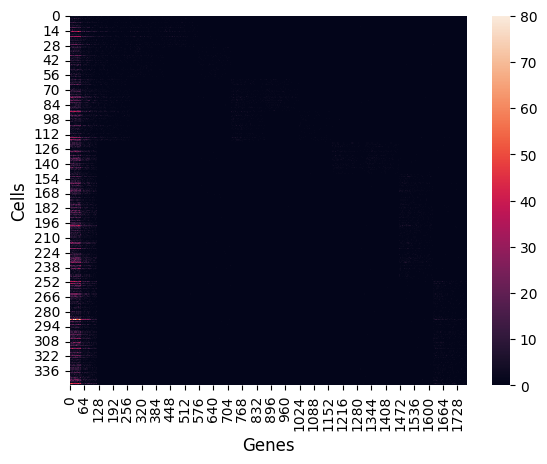

In [6]:
ADATA_PATH = REPO_ROOT / "datasets/adata_300.h5ad"
RESULT_PREFIX = ADATA_PATH.stem

adata = sc.read(ADATA_PATH)
num_cells = int(adata.n_obs)
num_genes = int(adata.n_vars)

print({"adata_path": str(ADATA_PATH), "num_cells": num_cells, "num_genes": num_genes})

def get_gene_module_labels(adata, col_name="gene_module"):
    pattern = re.compile(r"^g(?P<module>[A-Za-z0-9]+)_gb\d+_\d+$")
    labels = []
    for gene in adata.var_names.astype(str):
        match = pattern.match(gene)
        labels.append(match.group("module") if match else "NA")
    return pd.Series(labels, index=adata.var_names, name=col_name)

adata.var["gene_module"] = get_gene_module_labels(adata)
observed_gene_modules = sorted(
    label for label in adata.var["gene_module"].unique().tolist()
    if label not in {"NA", ""}
)
observed_cell_types = sorted(adata.obs["cell_type"].astype(str).unique().tolist()) if "cell_type" in adata.obs else []

print({
    "observed_gene_modules": observed_gene_modules,
    "observed_cell_types": observed_cell_types,
})

ax = sns.heatmap(adata.X)
ax.set_xlabel("Genes", fontsize=12)
ax.set_ylabel("Cells", fontsize=12)

In [ ]:
seed = 0

t_CME = 0.7
t_p = 0.4
t_Jaccard = 0.3
k_Jaccard = 297
n_permutations = 50

num_gene_modules = 12
num_gene_modules = max(1, min(num_gene_modules, num_genes))
num_hyperedges = num_gene_modules + 1

torch.manual_seed(seed)

run_config = {
    "seed": seed,
    "t_CME": t_CME,
    "t_p": t_p,
    "t_Jaccard": t_Jaccard,
    "k_Jaccard": k_Jaccard,
    "n_permutations": n_permutations,
    "num_gene_modules": num_gene_modules,
    "num_hyperedges": num_hyperedges,
}
run_config


{'seed': 0,
 't_CME': 0.7,
 't_p': 0.4,
 't_Jaccard': 0.3,
 'k_Jaccard': 297,
 'n_permutations': 50,
 'num_gene_modules': 12,
 'num_hyperedges': 13}

: 

C:\Users\Ideal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numba\core\decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


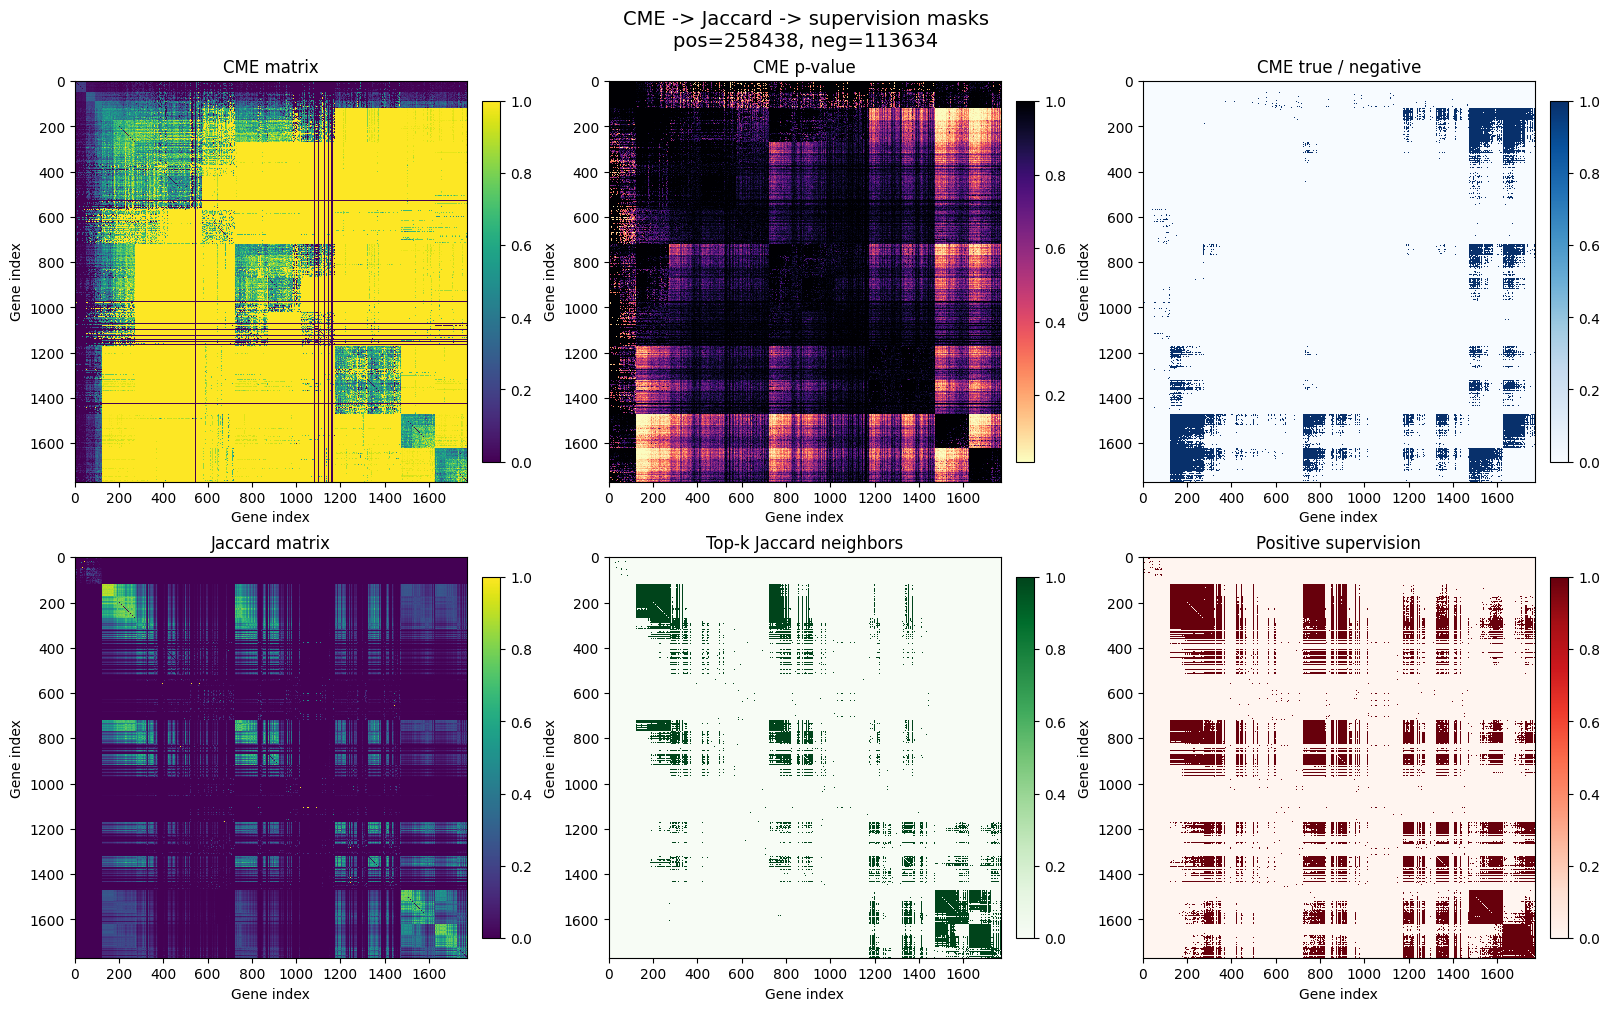

In [4]:
expression = load_expression_from_h5ad(
    ADATA_PATH,
    num_genes=num_genes,
)
cme_matrix = compute_cme_matrix(expression.matrix, normalize=False, use_numba=True)
pval_matrix = compute_cme_pvalues(
    expression.matrix,
    cme_matrix,
    n_permutations=n_permutations,
    seed=seed,
    use_numba=True,
)

supervision = build_supervision_from_cme(
    cme_matrix,
    pval_matrix,
    cme_threshold=t_CME,
    pvalue_threshold=t_p,
    jaccard_threshold=t_Jaccard,
    top_k=k_Jaccard,
)

pos_mask = torch.from_numpy(supervision.positive_mask)
neg_mask = torch.from_numpy(supervision.negative_mask)
supervision.stats

plot_cme_supervision_heatmaps(
    cme_matrix=cme_matrix,
    pval_matrix=pval_matrix,
    supervision=supervision,
    save_path=REPO_ROOT / f"results/{RESULT_PREFIX}_cme_supervision_heatmaps.png",
    show=True,
);


Epoch 1/10000, Loss: 0.155931443, pos(>= 0.5): 0.144906104, neg(->0): 0.008587473, Entropy: 2.4379
Epoch 100/10000, Loss: 0.036624584, pos(>= 0.5): 0.019945592, neg(->0): 0.014556346, Entropy: 2.1226
Epoch 200/10000, Loss: 0.030082133, pos(>= 0.5): 0.016982920, neg(->0): 0.011334397, Entropy: 1.7648
Epoch 300/10000, Loss: 0.021663655, pos(>= 0.5): 0.011268892, neg(->0): 0.009080033, Entropy: 1.3147
Epoch 400/10000, Loss: 0.020453591, pos(>= 0.5): 0.010584043, neg(->0): 0.008752173, Entropy: 1.1174
Epoch 500/10000, Loss: 0.019935543, pos(>= 0.5): 0.010361538, neg(->0): 0.008570252, Entropy: 1.0038
Epoch 600/10000, Loss: 0.019592989, pos(>= 0.5): 0.010229066, neg(->0): 0.008449974, Entropy: 0.9139
Epoch 700/10000, Loss: 0.019341432, pos(>= 0.5): 0.010140660, neg(->0): 0.008363954, Entropy: 0.8368
Epoch 800/10000, Loss: 0.019058472, pos(>= 0.5): 0.010079948, neg(->0): 0.008209755, Entropy: 0.7688
Epoch 900/10000, Loss: 0.018601030, pos(>= 0.5): 0.009954575, neg(->0): 0.007948900, Entropy:

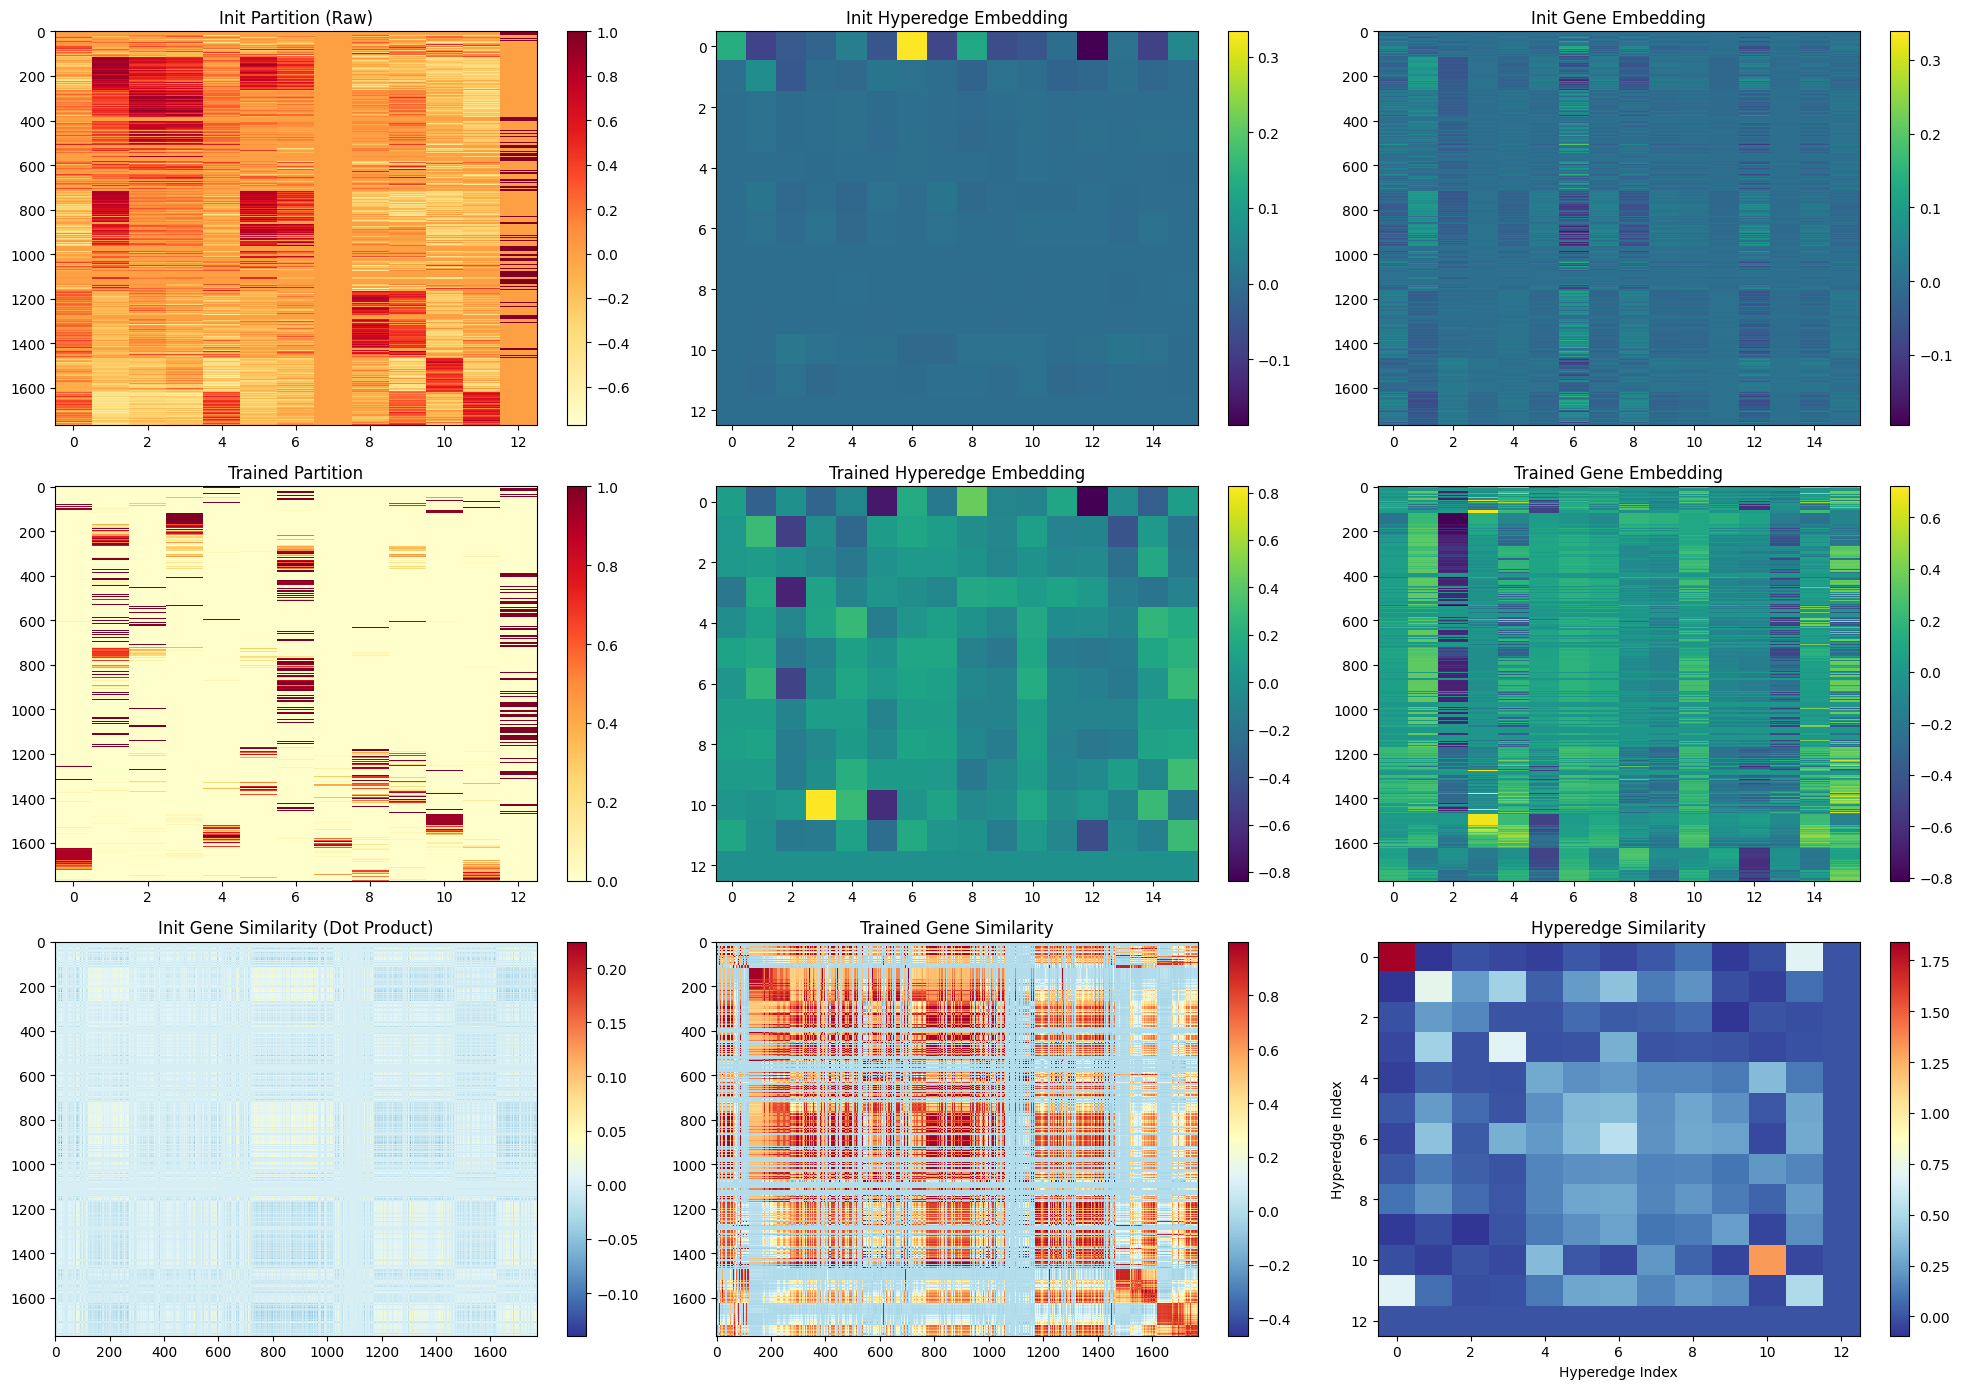

In [29]:
# ===== 正负监督 -> 超边 gene modules =====
result = run_supervised_hyperedges(
    adata=adata,
    pos_mask=pos_mask,
    neg_mask=neg_mask,
    partial_pos_mask=None,
    num_genes=num_genes,
    num_hyperedges=num_hyperedges,
    use_unassigned_hyperedge=True,
    pos_strength=0.5,
    neg_strength=0.0,
    epochs=10000,
    lr=0.016,
    entropy_strength=0.001,
    ranges_map=None,
    device="auto",
    seed=seed,
)

partition = result.partition
hyperedge_emb = result.hyperedge_emb
gene_emb = result.gene_emb
losses = result.losses

summarize_unassigned_genes(result)

plot_run_summary(result);


## ✅ 基因模块识别准确率：**44.49%**

{'overall_accuracy_percent': '44.49%',
 'correct_genes': 650,
 'evaluable_genes': 1461}

{'num_modules': 12,
 'num_nodes_with_empty': 13,
 'empty_node_index': 12,
 'root_index': 12,
 'root_is_empty_node': True,
 'cme_threshold': 0.76,
 'mutex_edges': 6,
 'complement_edges': 72,
 'tree_edges': 12,
 'empty_modules': 0,
 'assignment': 'argmax',
 'aggregation': 'sum',
 'child_strategy': 'max_degree_ties',
 'assignment_total_correct': 650,
 'assignment_total_evaluable': 1461,
 'weighted_assignment_accuracy': 0.44490075290896647}

,node_index,hyperedge,num_genes,evaluable_genes,identified_module,identified_count,accuracy,missing_reference,label_counts
0,0,0,109,109,E,77,0.706422,0,"{'Root': 15, 'A2': 2, 'B2': 3, 'R2': 6, 'C1': ..."
1,1,1,276,276,R1,65,0.235507,0,"{'R1': 65, 'R3': 21, 'A1': 34, 'A2': 45, 'R4':..."
2,2,2,62,62,A1,18,0.290323,0,"{'R3': 7, 'A1': 18, 'A2': 10, 'R4': 3, 'B1': 6..."
3,3,3,103,103,R1,83,0.805825,0,"{'R1': 83, 'R3': 5, 'A1': 6, 'A2': 6, 'B1': 1,..."
4,4,4,64,64,D,50,0.781250,0,"{'Root': 12, 'A2': 1, 'C1': 1, 'D': 50}"
5,5,5,47,47,R2,23,0.489362,0,"{'Root': 1, 'A2': 1, 'B1': 1, 'R2': 23, 'C1': 21}"
6,6,6,381,381,B1,89,0.233596,0,"{'Root': 26, 'R1': 2, 'R3': 80, 'A1': 47, 'A2'..."
7,7,7,27,27,D,25,0.925926,0,"{'C1': 2, 'D': 25}"
8,8,8,103,103,R2,46,0.446602,0,"{'Root': 1, 'A2': 2, 'B1': 1, 'R2': 46, 'C1': ..."
9,9,9,107,107,C1,42,0.392523,0,"{'Root': 6, 'R3': 17, 'A2': 8, 'R2': 34, 'C1':..."


{'num_nodes': 13,
 'tree_edges': 12,
 'tree_has_all_nodes': True,
 'tree_edge_count_ok': True,
 'root_is_empty_node': True,
 'mutex_graph_is_symmetric': True,
 'complement_graph_is_symmetric': True}

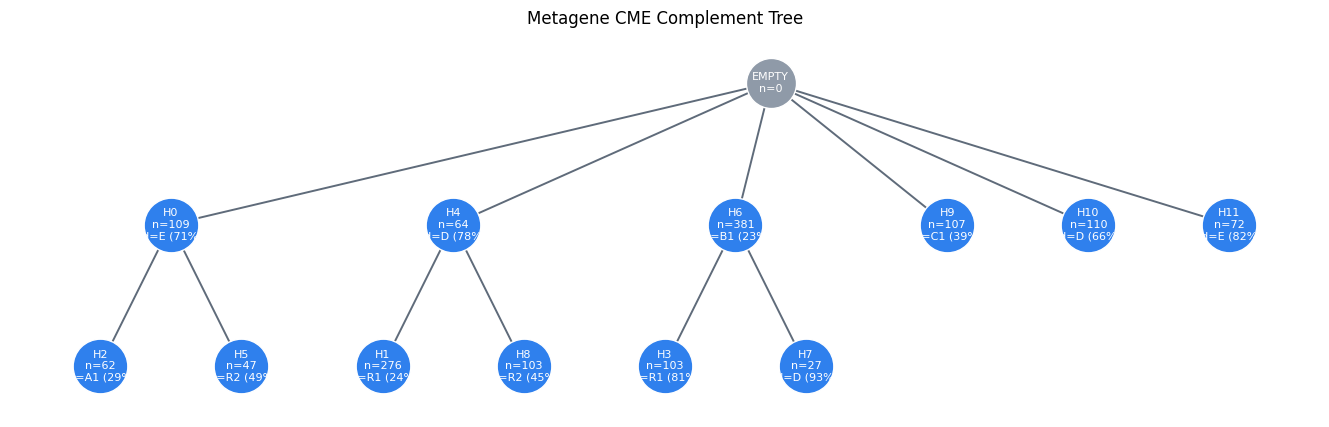

In [32]:
# ===== 超边 metagene CME -> 互斥图补图 -> 度优先树 =====
metagene_tree = build_metagene_tree_from_result(
    result,
    expression.matrix,
    adata=adata,
    gene_names=expression.gene_names,
    reference_column="gene_module",
    cme_threshold=t_CME,
    assignment="argmax",
    aggregation="sum",
    child_strategy="max_degree_ties",
)

tree_validation = validate_metagene_tree_result(metagene_tree)
assert tree_validation["tree_has_all_nodes"]
assert tree_validation["tree_edge_count_ok"]
assert tree_validation["root_is_empty_node"]

overall_accuracy = metagene_tree.stats.get("weighted_assignment_accuracy")
overall_accuracy_summary = {
    "overall_accuracy_percent": None if overall_accuracy is None else f"{overall_accuracy:.2%}",
    "correct_genes": metagene_tree.stats.get("assignment_total_correct"),
    "evaluable_genes": metagene_tree.stats.get("assignment_total_evaluable"),
}

from IPython.display import display, Markdown

acc = overall_accuracy_summary["overall_accuracy_percent"]
display(Markdown(f"## ✅ 基因模块识别准确率：**{acc}**"))

display(overall_accuracy_summary)
display(metagene_tree.stats)
display(pd.DataFrame(metagene_tree.module_assignment_table))
display(tree_validation)

fig = plot_metagene_tree(
    metagene_tree,
    save_path=REPO_ROOT / f"results/{RESULT_PREFIX}_metagene_cme_tree.png",
)


In [31]:
# ===== metagene score -> cell type 判断 =====
if "cell_type" not in adata.obs:
    raise ValueError("adata.obs 里没有 'cell_type' 列，不能计算细胞类型准确度。")

cell_type_result = score_cell_types_from_metagene_tree(
    metagene_tree,
    adata=adata,
    obs_column="cell_type",
)
cell_type_accuracy_summary = {
    "cell_type_accuracy": cell_type_result.stats["cell_type_accuracy"],
    "cell_type_accuracy_percent": f"{cell_type_result.stats['cell_type_accuracy']:.2%}",
    "correct_cells": cell_type_result.stats["cell_type_total_correct"],
    "evaluable_cells": cell_type_result.stats["cell_type_total_evaluable"],
}
acc_pct = f"{cell_type_result.stats['cell_type_accuracy']:.2%}"
display(Markdown(f"## ✅ 细胞类型识别准确率：**{acc_pct}**"))
display(cell_type_accuracy_summary)
display(pd.DataFrame(cell_type_result.metagene_cell_type_table))


# ===== subtype -> parent type 从属关系判断 =====
hierarchy_result = score_cell_hierarchy_from_cell_types(cell_type_result)
hierarchy_accuracy_summary = {
    "hierarchy_accuracy": hierarchy_result.stats["hierarchy_accuracy"],
    "hierarchy_accuracy_percent": f"{hierarchy_result.stats['hierarchy_accuracy']:.2%}",
    "correct_cells": hierarchy_result.stats["hierarchy_total_correct"],
    "evaluable_cells": hierarchy_result.stats["hierarchy_total_evaluable"],
}
hierarchy_acc_pct = f"{hierarchy_result.stats['hierarchy_accuracy']:.2%}"
display(Markdown(f"## ✅ 细胞从属关系识别准确率：**{hierarchy_acc_pct}**"))
display(hierarchy_accuracy_summary)
display(pd.DataFrame(hierarchy_result.hierarchy_relation_table))


## ✅ 细胞类型识别准确率：**44.29%**

{'cell_type_accuracy': 0.44285714285714284,
 'cell_type_accuracy_percent': '44.29%',
 'correct_cells': 155,
 'evaluable_cells': 350}

,node_index,hyperedge,identified_cell_type,mean_score,assigned_cells,evaluable_assigned_cells,correct_assigned_cells,assigned_accuracy
0,1,1,B1,46.700001,5,5,4,0.800000
1,2,2,A1,4.966667,0,0,0,NaN
2,3,3,B2,49.500000,33,33,8,0.242424
3,5,5,C1,29.833334,0,0,0,NaN
4,7,7,D,3.180000,0,0,0,NaN
5,8,8,C1,28.533333,0,0,0,NaN
6,9,9,C1,44.033333,9,9,8,0.888889
7,10,10,D,98.580002,270,270,100,0.370370
8,11,11,E,59.860001,49,49,39,0.795918


## ✅ 细胞从属关系识别准确率：**46.29%**

{'hierarchy_accuracy': 0.46285714285714286,
 'hierarchy_accuracy_percent': '46.29%',
 'correct_cells': 162,
 'evaluable_cells': 350}

,predicted_cell_type,predicted_parent_type,assigned_cells,correct_parent_cells,reference_parent_counts,parent_accuracy
0,B1,B,5,5,{'B': 5},1.000000
1,B2,B,33,14,"{'A': 19, 'B': 14}",0.424242
2,C1,C,9,8,"{'A': 1, 'C': 8}",0.888889
3,D,D,261,100,"{'A': 36, 'B': 39, 'C': 21, 'D': 100, 'E': 65}",0.383142
4,E,E,42,35,"{'A': 4, 'B': 2, 'C': 1, 'E': 35}",0.833333
